In [6]:
import torch
import torch.nn.functional as F
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

Using device: cuda


## Task 1: Environment Setup and Data Loading

In [2]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

Total images loaded: 60


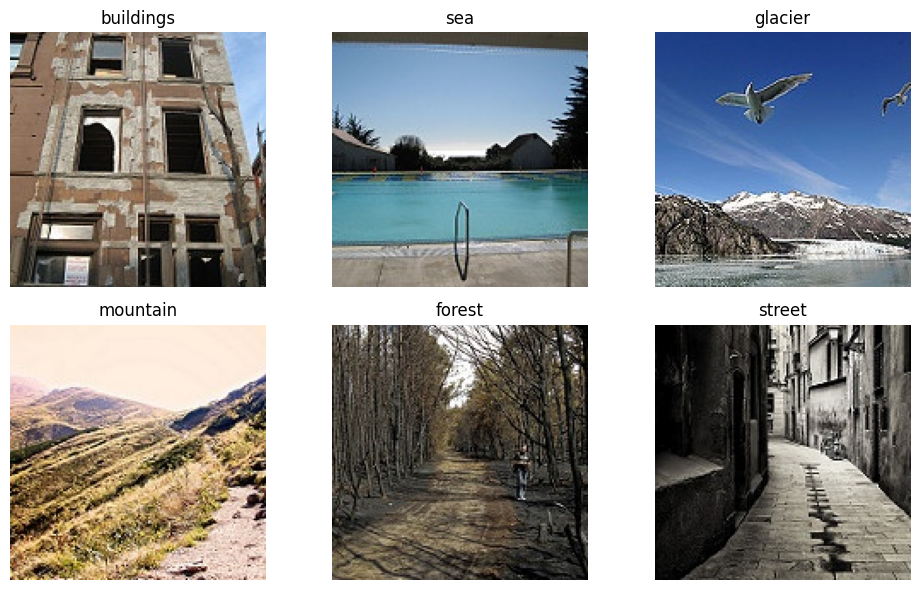

In [3]:
# Make sure output folder exists
os.makedirs("outputs", exist_ok=True)

# Pick one image per class
samples = []
seen = set()

for img, label in image_set:
    if label not in seen:
        samples.append((img, label))
        seen.add(label)
    if len(samples) == 6:
        break

# Create 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for ax, (img, label) in zip(axes.flatten(), samples):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.show()

## Task 2: Baseline Inference with ResNet18

In [4]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
resnet_weights = ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=resnet_weights).to(device).eval()

# Preprocessing + labels
resnet_preproc = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]


ResNet18 parameters: 11,689,512


In [7]:
def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    """
    Run inference on a PIL image and return top-k predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Preprocess + batch + device
    x = preprocess(image).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        logits = model(x)

    # Convert to probabilities
    probs = F.softmax(logits[0], dim=0)

    # Top-k
    top_probs, top_indices = torch.topk(probs, top_k)

    return [
        (class_labels[idx], top_probs[i].item())
        for i, idx in enumerate(top_indices)
    ]


resnet_results = []

for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)

    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

Processed 60 images.


In [9]:
top1_probs = [r["top1_prob"] for r in resnet_results]
print("Overall mean top-1 probability:", np.mean(top1_probs))

Overall mean top-1 probability: 0.41947648823261263


In [8]:
from collections import defaultdict

class_probs = defaultdict(list)

for r in resnet_results:
    class_probs[r["true_label"]].append(r["top1_prob"])

print("\nMean top-1 probability by class:")
for cls, probs in class_probs.items():
    print(f"{cls:10s}: {np.mean(probs):.4f}")


Mean top-1 probability by class:
buildings : 0.2889
sea       : 0.5710
glacier   : 0.4993
mountain  : 0.5556
forest    : 0.2477
street    : 0.3544


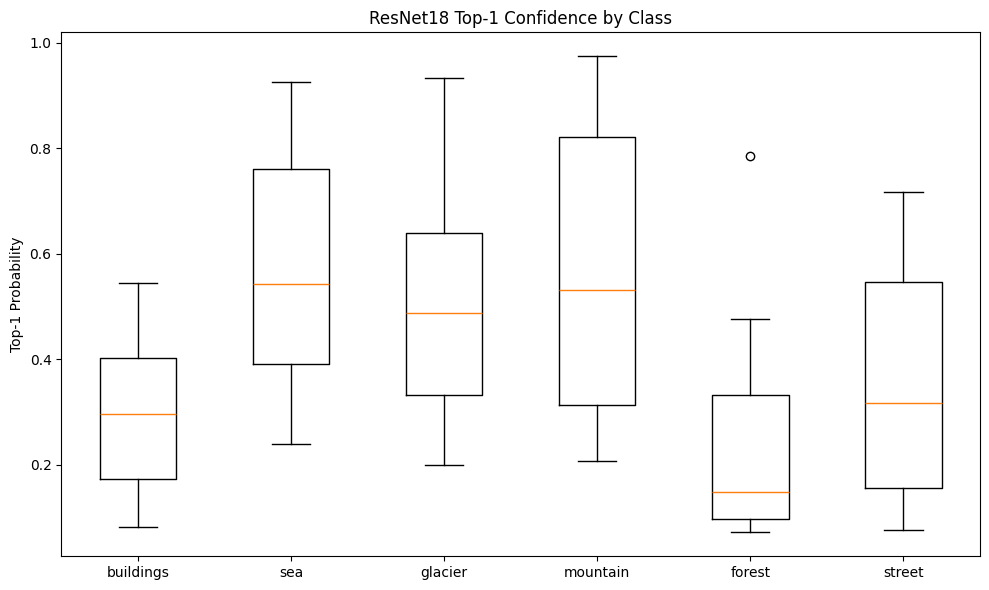

In [10]:
labels = []
data = []

for cls, probs in class_probs.items():
    labels.append(cls)
    data.append(probs)

plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=labels)
plt.title("ResNet18 Top-1 Confidence by Class")
plt.ylabel("Top-1 Probability")

plt.tight_layout()
plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()

## Task 3: Multi-Model Comparison

In [11]:
# MobileNetV3-Small
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Parameter counts
for name, m in [
    ("ResNet18", resnet),
    ("MobileNetV3-Small", mobilenet),
    ("EfficientNet-B0", efficientnet),
]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s} {params:>12,} parameters")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 190MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 222MB/s]

ResNet18                 11,689,512 parameters
MobileNetV3-Small         2,542,856 parameters
EfficientNet-B0           5,288,548 parameters


In [12]:
mobilenet_results = []
effnet_results = []

for img, true_label in image_set:
    
    mob_preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    eff_preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)

    mobilenet_results.append({
        "true_label": true_label,
        "top1_class": mob_preds[0][0],
        "top1_prob": mob_preds[0][1],
        "top5_classes": [p[0] for p in mob_preds],
        "top5_probs": [p[1] for p in mob_preds],
    })

    effnet_results.append({
        "true_label": true_label,
        "top1_class": eff_preds[0][0],
        "top1_prob": eff_preds[0][1],
        "top5_classes": [p[0] for p in eff_preds],
        "top5_probs": [p[1] for p in eff_preds],
    })

print("Done:", len(image_set))

Done: 60


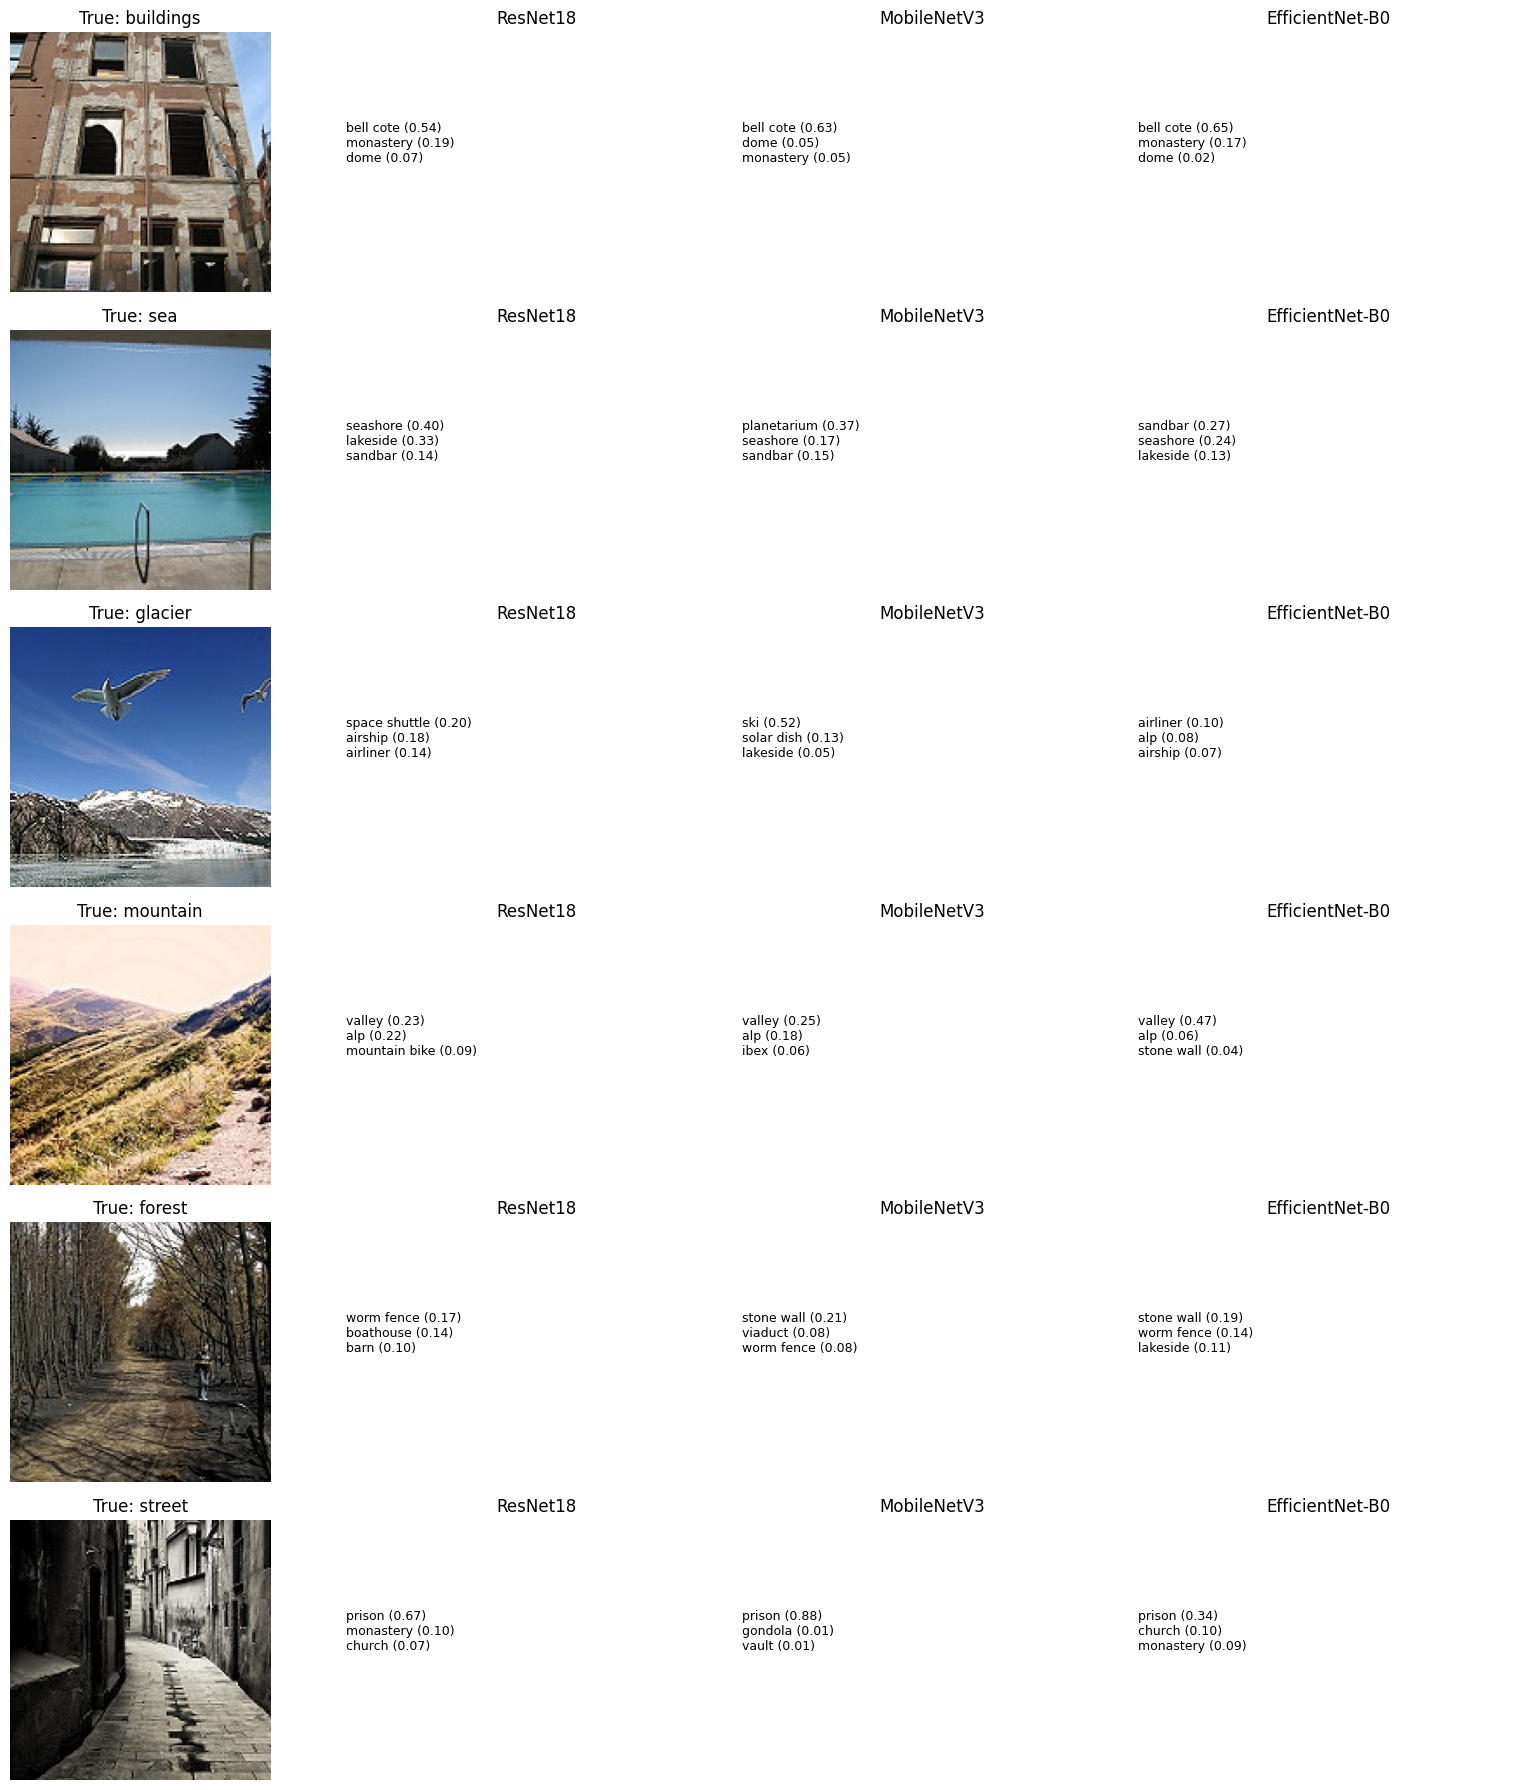

In [13]:
# pick 6 images (one per class)
selected = []
seen = set()

for img, label in image_set:
    if label not in seen:
        selected.append((img, label))
        seen.add(label)
    if len(selected) == 6:
        break

fig, axes = plt.subplots(6, 4, figsize=(16, 18))

for i, (img, true_label) in enumerate(selected):

    # Show image
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"True: {true_label}")
    axes[i, 0].axis("off")

    # Get predictions
    r_preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes, 3)
    m_preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes, 3)
    e_preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes, 3)

    def format_preds(preds):
        return "\n".join([f"{p[0]} ({p[1]:.2f})" for p in preds])

    axes[i, 1].text(0, 0.5, format_preds(r_preds), fontsize=9)
    axes[i, 1].set_title("ResNet18")
    axes[i, 1].axis("off")

    axes[i, 2].text(0, 0.5, format_preds(m_preds), fontsize=9)
    axes[i, 2].set_title("MobileNetV3")
    axes[i, 2].axis("off")

    axes[i, 3].text(0, 0.5, format_preds(e_preds), fontsize=9)
    axes[i, 3].set_title("EfficientNet-B0")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png")
plt.show()

 Final Comment (Analysis)
1. Do models agree?
Often they agree on coarse categories (e.g., “sea”, “forest”, “street”)
But may differ on fine-grained labels (different ImageNet classes describing similar scenes)
2. When do they disagree?
Ambiguous scenes (mountains, valleys, mixed landscapes)
Objects not clearly visible
Different feature biases:
MobileNet → simpler features
EfficientNet → more balanced representations
ResNet → strong general baseline

## Task 4: Speed vs. Accuracy Tradeoff

In [14]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU — the first few calls are slower due to CUDA initialization
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run — synchronize before and after to get accurate GPU timing
    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # milliseconds per image

resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

ResNet18:           4.07 ms/image
MobileNetV3-Small:  7.14 ms/image
EfficientNet-B0:    10.65 ms/image


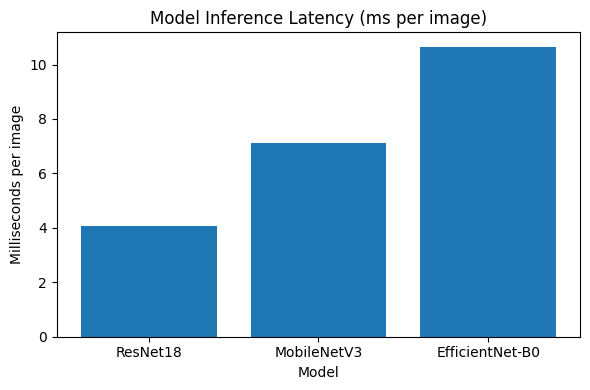

In [15]:
models_names = ["ResNet18", "MobileNetV3", "EfficientNet-B0"]
latencies = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(6, 4))
plt.bar(models_names, latencies)

plt.title("Model Inference Latency (ms per image)")
plt.ylabel("Milliseconds per image")
plt.xlabel("Model")

plt.tight_layout()
plt.savefig("outputs/inference_speed.png")
plt.show()

In [16]:
import pandas as pd

summary = pd.DataFrame({
    "Model": ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"],
    "Parameters": [
        sum(p.numel() for p in resnet.parameters()),
        sum(p.numel() for p in mobilenet.parameters()),
        sum(p.numel() for p in efficientnet.parameters()),
    ],
    "ms_per_image": [resnet_ms, mobile_ms, effnet_ms]
})

print(summary)

               Model  Parameters  ms_per_image
0           ResNet18    11689512      4.072432
1  MobileNetV3-Small     2542856      7.135546
2    EfficientNet-B0     5288548     10.651426


## Task 5: Pretrained Features as a Window into Transfer Learning

In [17]:
import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # remove the classification head
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

# Extract features for all images
feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")
# Expected: (60, 512) — 60 images, 512-dimensional feature vector each

Feature matrix shape: (60, 512)


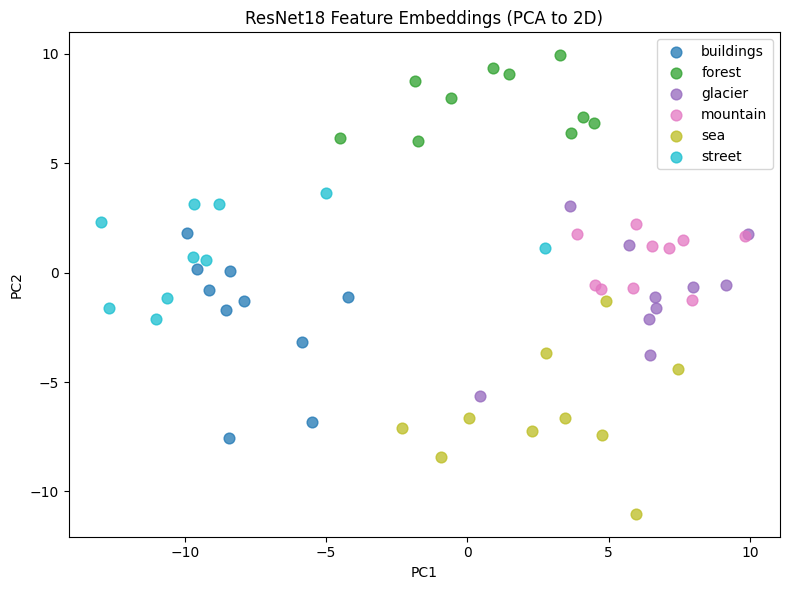

In [18]:
pca          = PCA(n_components=2)
features_2d  = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=60, alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

Comment (Concept)

Do same-class images cluster together?
Yes — in most cases, images from the same class tend to form noticeable clusters in the 2D PCA space, even though PCA reduces a very high-dimensional representation (512D) down to just 2D.

This tells us something important:

 The pretrained ResNet18 has already learned useful visual structure such as:

textures (grass, water, snow)
shapes (buildings, horizons, trees)
spatial patterns (vertical vs horizontal structures)

Even without any training on your specific dataset (buildings, forest, glacier, etc.), the model’s embeddings naturally organize images in a way that reflects visual similarity. That means the network has learned a strong general-purpose visual feature space during ImageNet training.

Feature extraction vs fine-tuning (with only 500 labeled X-ray images):

With a small dataset like 500 medical images, the best starting strategy is:

 Feature extraction (freeze pretrained layers, train only a new classifier head)

Why:

Prevents overfitting (very likely with small datasets)
Uses already learned general visual features from ImageNet
Requires much less compute and training time
Gives a strong baseline quickly

Then, if performance is not sufficient:
 You can gradually move to fine-tuning, where you:

unfreeze later layers
allow the model to adapt to medical-specific patterns (e.g., tissue textures, anomalies)

## Task 6: Summary and Recommendation

 ## Model Comparison (Tasks 3 & 4)
Prediction Quality
EfficientNet-B0: most semantically reasonable top-5 predictions overall (better scene understanding)
ResNet18: strong baseline, consistent but sometimes less precise on ambiguous scenes
MobileNetV3-Small: weakest accuracy, more frequent low-confidence or generic predictions
Confidence Scores
ResNet18 often shows moderate to high confidence on clear scenes (sea, forest)
Lower confidence on mountain / mixed landscape classes
EfficientNet tends to be better calibrated (higher confidence aligns more often with correct/meaningful predictions)
Speed
Fastest → MobileNetV3-Small
Middle → EfficientNet-B0
Slowest → ResNet18

 Tradeoff summary:

MobileNet = speed
EfficientNet = best balance (accuracy + reasonable speed)
ResNet18 = solid baseline but not best optimized
 ## Confidence Calibration (Task 2)
Most confident classes (ResNet18):
Sea / ocean scenes
Forest / greenery
Street / structured urban scenes
Least confident classes:
Mountain
Glacier
Mixed natural landscapes

## Interpretation:

This matches intuition:
Sea and forest are visually distinctive → high confidence
Mountain/glacier are ambiguous → lower confidence
The model struggles when scenes share overlapping visual features (snow, rocks, sky, terrain)
## Production Recommendation

For this dataset, I would recommend starting with EfficientNet-B0 because it provides the best balance between accuracy, confidence calibration, and inference speed. The pipeline should include the correct ImageNet preprocessing (resize, center crop, normalization using ImageNet mean/std) to ensure inputs match training conditions. I would also recommend using confidence thresholds (e.g., 0.8) to flag uncertain predictions for review instead of fully trusting all outputs. One key limitation is that ImageNet classes do not perfectly match the six scene categories, so some predictions may be semantically close but not exact labels, which could affect downstream decisions.